In [10]:
import os
import sys

from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.Benchmark import db_hit_compare as dc


In [12]:
if os.path.exists(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_level_db_hits.csv'):
    rates = pd.read_csv(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_level_db_hits.csv')
    persample_summary = pd.read_csv(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_level_db_hits_per_sample_summary.csv')
else:   
    rates, persample_summary = dc.gene_level_db_hits(save=True)
print('== gene-level DB-hit rate (cohort-level sets) ==')
display(rates[rates.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))
print()
print('== per-patient normative rate distribution (median across patients) ==')
display(persample_summary)


== gene-level DB-hit rate (cohort-level sets) ==


,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov,49,2,0.041,True
1,Colorectal Cancer,deseq2_no_cov,10041,192,0.019,True
2,Colorectal Cancer,normative_union,1281,25,0.020,True
3,Esophagus Cancer,deseq2_cov,24,1,0.042,True
4,Esophagus Cancer,deseq2_no_cov,432,12,0.028,True
5,Esophagus Cancer,normative_union,233,4,0.017,True
6,HIV,deseq2_cov,39,3,0.077,True
7,HIV,deseq2_no_cov,52,4,0.077,True
8,HIV + Tuberculosis,deseq2_cov,11,1,0.091,True
9,HIV + Tuberculosis,deseq2_no_cov,321,23,0.072,True



== per-patient normative rate distribution (median across patients) ==


,phenotype,median,count
0,Colorectal Cancer,0.0,23
1,Esophagus Cancer,0.0,20
2,Liver Cancer,0.0,34
3,Lung Cancer,0.0,23
4,Pancreatic Cancer,0.0,69
5,Pancreatitis,0.0,77
6,Pre-eclampsia,0.0,39
7,Stomach Cancer,0.0,17
8,Tuberculosis,0.0,56


In [16]:
import numpy as np
import pickle
from scipy.stats import norm
from MixedEffectsModeling.core.calibration import bh_fdr_reject

if os.path.exists(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_fdr_sweep.csv'):
    sweep = pd.read_csv(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_fdr_sweep.csv')
else:
    Z = np.load('Z_scores_mixed/Z_disease.npy')
    gene_names = pickle.load(open('Z_scores_mixed/gene_names.pkl', 'rb'))
    sm = pd.read_csv('Z_scores_mixed/sample_meta.csv')
    sym_of_raw = dc.ensg_to_symbol()
    sym_of = sym_of_raw.reindex(gene_names).values
    sym_of_base = sym_of_raw.copy()
    sym_of_base.index = sym_of_base.index.str.split('.').str[0]
    ref = dc.load_reference()
    p_all = 2 * norm.sf(np.abs(Z))

    QS = [0.01, 0.05, 0.1, 0.2, 0.3]
    summary_csv = pd.read_csv('Benchmark/DESeq2/summary.csv')
    sweep_rows = []
    for pheno in ref:
        idx = np.where((sm.phenotype == pheno).values & sm.ood_keep.values)[0]
        if len(idx) == 0:
            continue
        for q in QS:
            union = set()
            for i in idx:
                row = p_all[i]
                finite = np.isfinite(row)
                reject = np.zeros(len(row), dtype=bool)
                reject[finite] = bh_fdr_reject(row[finite], q=q)
                union |= set(sym_of[reject])
            sweep_rows.append(dict(dc.db_hit_row(pheno, 'normative', union, ref), q=q))

        studies = summary_csv[(summary_csv.design == 'covariate') & (summary_csv.phenotype == pheno)]
        for q in QS:
            union = set()
            for _, r in studies.iterrows():
                path = Path('Benchmark/DESeq2/covariate') / f"{dc.deseq2_tag(r.study, pheno)}.csv"
                if not path.exists():
                    continue
                res = pd.read_csv(path, index_col=0)
                res.index = res.index.str.split('.').str[0]
                sig = res.index[res.padj < q]
                union |= set(sym_of_base.reindex(sig).dropna())
            if len(studies):
                sweep_rows.append(dict(dc.db_hit_row(pheno, 'deseq2_cov', union, ref), q=q))

    sweep = pd.DataFrame(sweep_rows)
    sweep.to_csv(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_fdr_sweep.csv', index=False)
display(sweep.pivot_table(index=['phenotype', 'q'], columns='method', values='db_hit_rate'))

method                  deseq2_cov  normative
phenotype         q                          
Colorectal Cancer 0.01       0.000      0.020
                  0.05       0.041      0.020
                  0.10       0.028      0.018
                  0.20       0.020      0.017
                  0.30       0.016      0.016
...                            ...        ...
Tuberculosis      0.01       0.121      0.032
                  0.05       0.086      0.020
                  0.10       0.063      0.017
                  0.20       0.036      0.016
                  0.30       0.032      0.015

[70 rows x 2 columns]

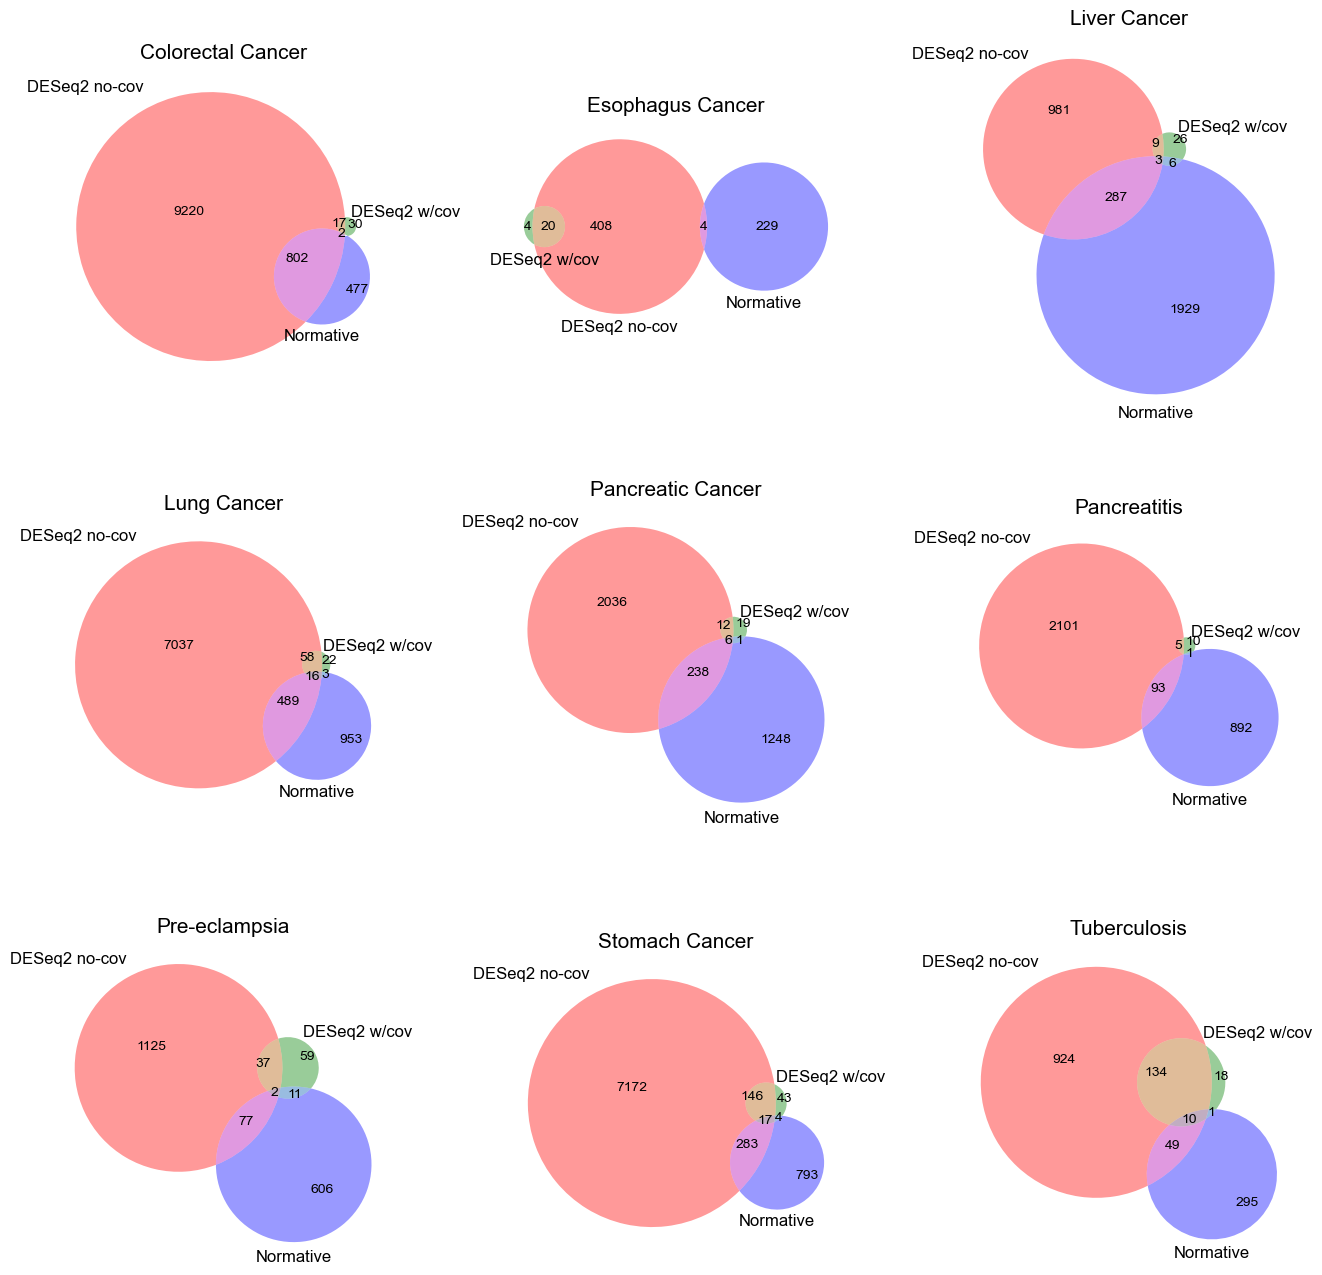

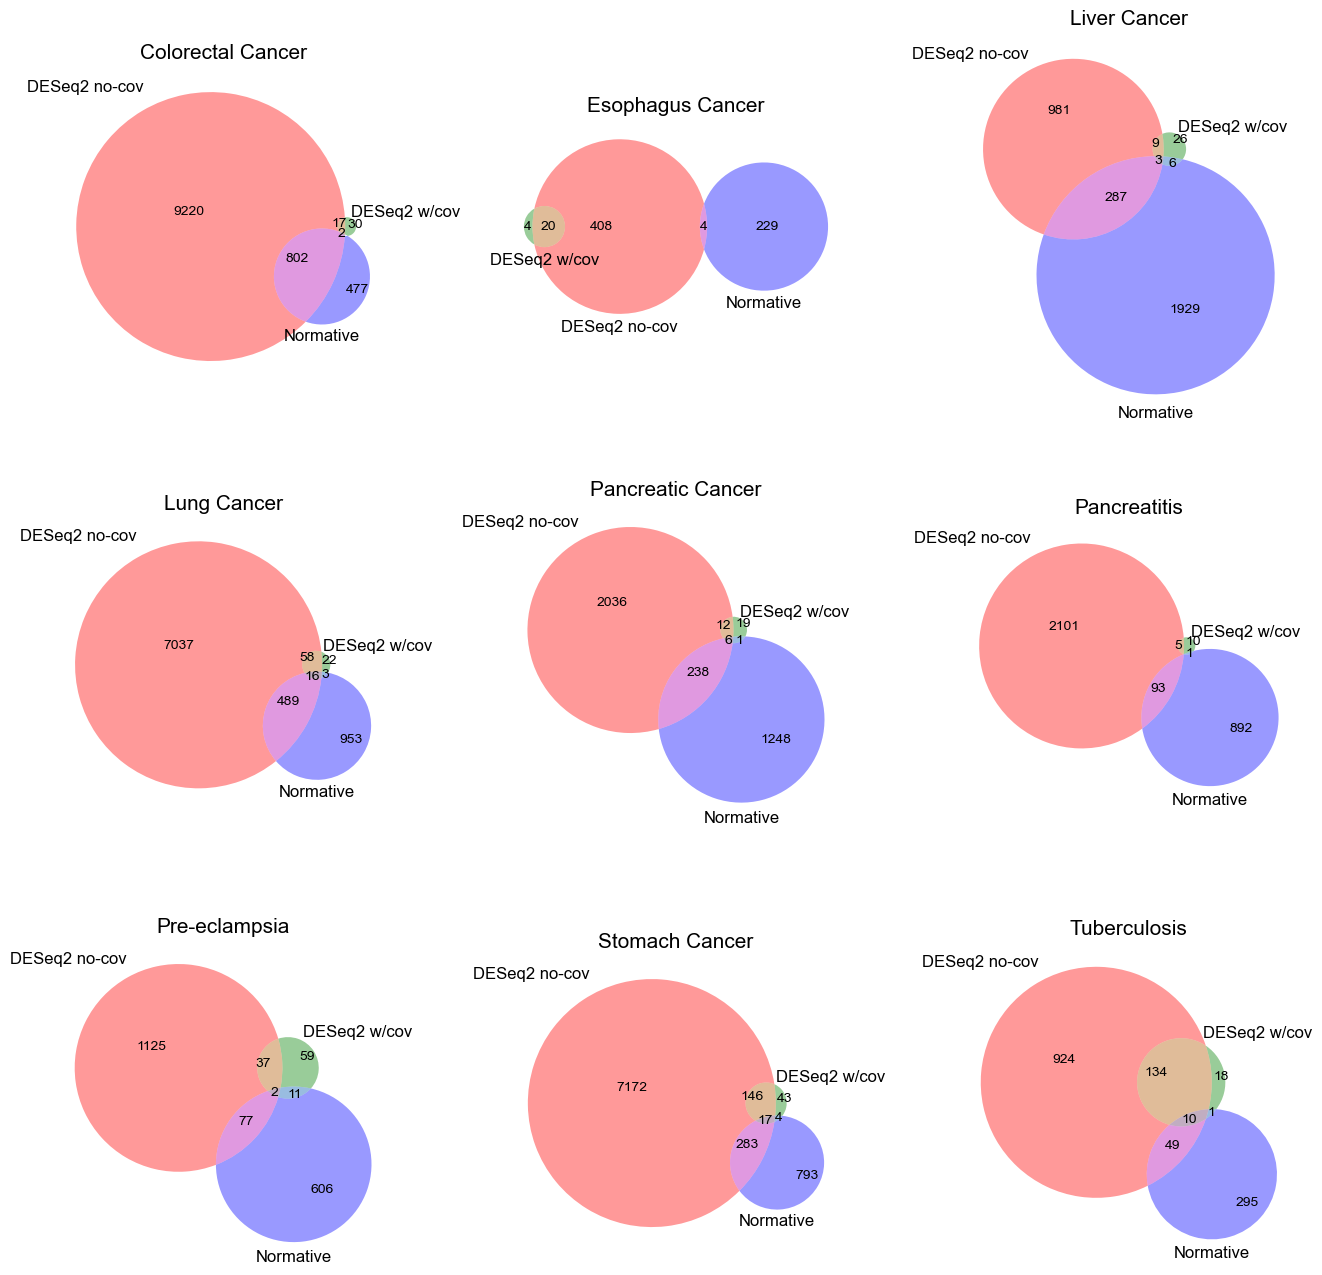

In [15]:
dc.plot_gene_venn(ncols=3, save=True)

In [17]:
if os.path.exists(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'pathway_level_db_hits.csv'):
    path_rates = pd.read_csv(config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'pathway_level_db_hits.csv')
else:
    path_rates = dc.pathway_level_db_hits(save=True)
display(path_rates[path_rates.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov,0,0,NaN,True
1,Colorectal Cancer,deseq2_no_cov,184,79,0.429,True
2,Colorectal Cancer,normative_union,1200,421,0.351,True
3,Esophagus Cancer,deseq2_cov,6,0,0.000,True
4,Esophagus Cancer,deseq2_no_cov,271,157,0.579,True
5,Esophagus Cancer,normative_union,1048,357,0.341,True
6,Liver Cancer,deseq2_cov,93,23,0.247,True
7,Liver Cancer,deseq2_no_cov,415,158,0.381,True
8,Liver Cancer,normative_union,1208,432,0.358,True
9,Lung Cancer,deseq2_cov,6,3,0.500,True


In [18]:
dc.plot_db_hit_bars(path_rates, 'Pathway-level DB-hit', 'pathway_db_hit_bars.png')

AttributeError: module 'MixedEffectsModeling.Benchmark.db_hit_compare' has no attribute 'plot_db_hit_bars'